# 🧹 Autoencoder for Image Denoising — MNIST

**Celebal Technologies Internship | Deep Learning Project**

---

## 📌 Project Overview

An **Autoencoder** is an unsupervised neural network that learns a **compressed representation** (latent space) of input data and then reconstructs it. In this notebook, we use it for **Image Denoising**:

```
Noisy Image ──► Encoder ──► Latent Vector ──► Decoder ──► Clean Image
```

### Architecture
| Component | Role |
|-----------|------|
| **Encoder** | Compresses 28×28 image into a small bottleneck |
| **Bottleneck** | Latent representation (e.g., 64-dim vector) |
| **Decoder** | Reconstructs clean image from compressed code |

### What we build
- ✅ Model 1 — Fully-Connected (FC) Autoencoder
- ✅ Model 2 — Convolutional Autoencoder (ConvAE) with Transpose Convolutions
- ✅ Gaussian noise injection for training
- ✅ Visual comparison: Noisy → Denoised → Original
- ✅ Loss curves & PSNR metric


## 📦 1. Install & Import Libraries

In [1]:
# ── Core Libraries ──────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import math

# ── PyTorch ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split

# ── Torchvision ─────────────────────────────────────────────────────────
from torchvision import datasets, transforms

# ── Reproducibility ─────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Device ──────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')


Using device: cuda
  GPU: Tesla T4


## 📂 2. Load & Prepare MNIST Dataset

In [2]:
# ── Transform: normalize to [0, 1] ─────────────────────────────────────
transform = transforms.Compose([transforms.ToTensor()])

# ── Download MNIST ──────────────────────────────────────────────────────
train_full = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# ── Train / Validation Split (80/20) ───────────────────────────────────
val_size   = int(0.2 * len(train_full))
train_size = len(train_full) - val_size
train_data, val_data = random_split(train_full, [train_size, val_size])

# ── DataLoaders ─────────────────────────────────────────────────────────
BATCH_SIZE = 128

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)} ({train_size} images)')
print(f'Val   batches : {len(val_loader)}   ({val_size} images)')
print(f'Test  batches : {len(test_loader)}  ({len(test_data)} images)')


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]

Train batches : 375 (48000 images)
Val   batches : 94   (12000 images)
Test  batches : 79  (10000 images)


## 🔊 3. Add Gaussian Noise — Denoising Task Setup

> **Key idea:** We deliberately corrupt the input images with Gaussian noise, then train the autoencoder to output the **original clean image**. This forces the network to learn meaningful structure, not just copy pixels.


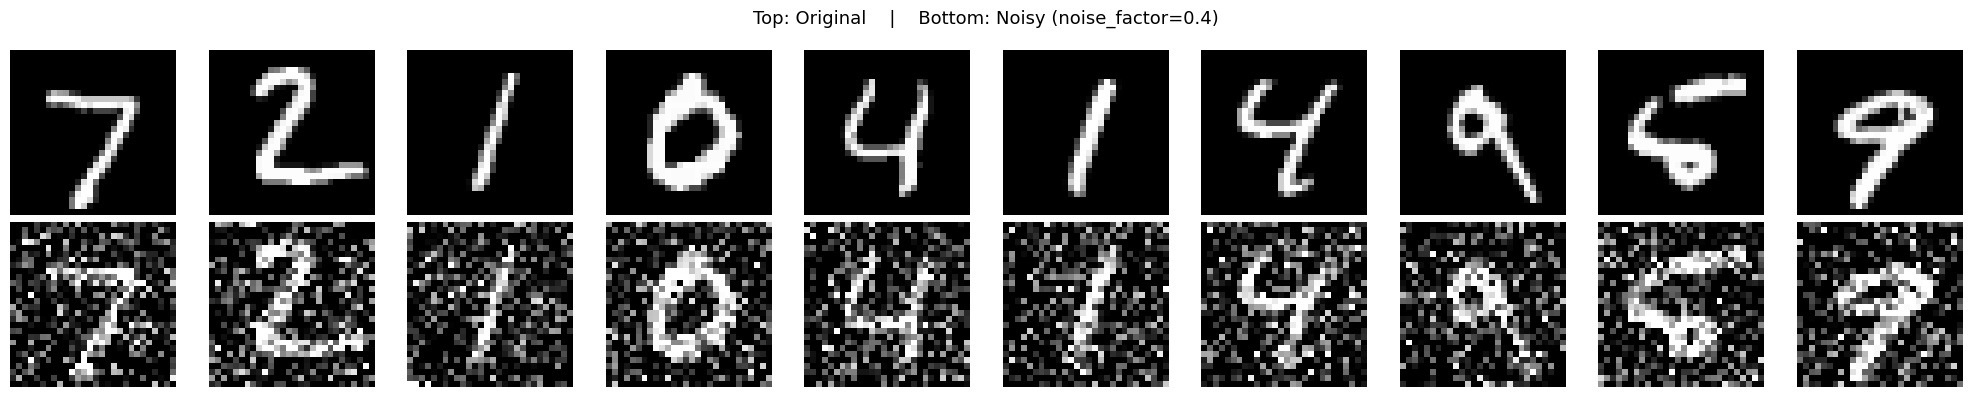

In [3]:
def add_noise(images, noise_factor=0.4):
    """
    Add Gaussian noise to a batch of images.
    Args:
        images      : Tensor (B, C, H, W) with values in [0, 1]
        noise_factor: std of the Gaussian noise
    Returns:
        Noisy tensor clamped to [0, 1]
    """
    noise = torch.randn_like(images) * noise_factor
    return torch.clamp(images + noise, 0.0, 1.0)


# ── Visualise the noise effect ──────────────────────────────────────────
NOISE_FACTOR = 0.4   # define globally here for use throughout notebook

sample_imgs, _ = next(iter(test_loader))
sample_noisy   = add_noise(sample_imgs, NOISE_FACTOR)

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
fig.suptitle('Top: Original    |    Bottom: Noisy (noise_factor=0.4)', fontsize=13)

for i in range(10):
    axes[0, i].imshow(sample_imgs[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(sample_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


## 🏗️ 4. Model Architectures

### Model 1 — Fully Connected (FC) Autoencoder
Simple baseline: flattens the 28×28 image → encoder layers → bottleneck (64-dim) → decoder layers → reshape back.


In [4]:
class FCAutoencoder(nn.Module):
    """
    Fully-Connected Denoising Autoencoder.
    Encoder: 784 -> 256 -> 128 -> latent_dim
    Decoder: latent_dim -> 128 -> 256 -> 784
    """
    def __init__(self, latent_dim=64):
        super(FCAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, latent_dim),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.2),
            nn.Linear(256, 784),
            nn.Sigmoid(),   # output in [0,1] to match normalised pixel values
        )

    def forward(self, x):
        batch = x.size(0)
        x   = x.view(batch, -1)    # flatten
        z   = self.encoder(x)
        out = self.decoder(z)
        return out.view(batch, 1, 28, 28)


# Sanity check
fc_model = FCAutoencoder(latent_dim=64).to(device)
dummy    = torch.zeros(4, 1, 28, 28).to(device)
out      = fc_model(dummy)
print(f'FCAutoencoder | Input: {dummy.shape} | Output: {out.shape}')
print(f'Parameters: {sum(p.numel() for p in fc_model.parameters()):,}')
print(fc_model)


FCAutoencoder | Input: torch.Size([4, 1, 28, 28]) | Output: torch.Size([4, 1, 28, 28])
Parameters: 486,480
FCAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=128, out_features=256, bias=True)
    (4): ReLU()
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Dropout(p=0.2, inplace=False

### Model 2 — Convolutional Autoencoder (ConvAE)
Uses Conv2d in the encoder and ConvTranspose2d in the decoder.  
Spatial hierarchy preserved → better image reconstruction.

```
Encoder: (1,28,28) → Conv+Pool → (32,14,14) → Conv+Pool → (64,7,7) → Conv → (128,7,7)
Decoder: (128,7,7) → ConvT → (64,7,7) → ConvT → (32,14,14) → ConvT → (1,28,28)
```


In [5]:
class ConvAutoencoder(nn.Module):
    """Convolutional Denoising Autoencoder with Transpose-Convolution decoder."""

    def __init__(self):
        super(ConvAutoencoder, self).__init__()

        # ── Encoder ─────────────────────────────────────────────────────
        self.encoder = nn.Sequential(
            # Block 1: (1,28,28) -> (32,28,28) -> (32,14,14)
            nn.Conv2d(1,  32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2, 2),

            # Block 2: (32,14,14) -> (64,14,14) -> (64,7,7)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2),

            # Block 3: deeper features (64,7,7) -> (128,7,7)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
        )

        # ── Decoder ─────────────────────────────────────────────────────
        self.decoder = nn.Sequential(
            # (128,7,7) -> (64,7,7)
            nn.ConvTranspose2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            # (64,7,7) -> (32,14,14)
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            # (32,14,14) -> (1,28,28)
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


# Sanity check
conv_model = ConvAutoencoder().to(device)
dummy      = torch.zeros(4, 1, 28, 28).to(device)
out        = conv_model(dummy)
print(f'ConvAutoencoder | Input: {dummy.shape} | Output: {out.shape}')
print(f'Parameters: {sum(p.numel() for p in conv_model.parameters()):,}')
print(conv_model)


ConvAutoencoder | Input: torch.Size([4, 1, 28, 28]) | Output: torch.Size([4, 1, 28, 28])
Parameters: 175,457
ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): 

## ⚙️ 5. Training Setup — Loss, Optimizer, Scheduler

In [6]:
import math

# ── Hyperparameters ─────────────────────────────────────────────────────
EPOCHS = 20
LR     = 1e-3

# MSE loss penalises pixel-level error; valid since outputs are in [0,1]
criterion = nn.MSELoss()


def make_optimizer_scheduler(model):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    return optimizer, scheduler


def psnr(mse, max_pixel=1.0):
    """Peak Signal-to-Noise Ratio. Higher = better denoising."""
    if mse == 0:
        return float('inf')
    return 20 * math.log10(max_pixel / math.sqrt(mse))


print(f'Epochs: {EPOCHS} | LR: {LR} | Noise factor: {NOISE_FACTOR}')

Epochs: 20 | LR: 0.001 | Noise factor: 0.4


## 🏋️ 6. Training Loop

> **Denoising training rule:**
> - **Input to model** = noisy image
> - **Loss target** = original clean image
> - The model learns to map `noisy → clean`


In [7]:
def train_model(model, name, epochs=EPOCHS):
    optimizer, scheduler = make_optimizer_scheduler(model)
    history = {'train_loss': [], 'val_loss': [], 'val_psnr': []}
    best_val  = float('inf')
    best_path = f'{name}_best.pth'

    print(f'\n{"="*60}')
    print(f'  Training: {name}')
    print(f'{"="*60}')

    for epoch in range(1, epochs + 1):

        # ── TRAIN ───────────────────────────────────────────────────────
        model.train()
        running_train = 0.0
        for clean, _ in train_loader:
            clean = clean.to(device)
            noisy = add_noise(clean, NOISE_FACTOR).to(device)

            optimizer.zero_grad()
            output = model(noisy)
            loss   = criterion(output, clean)   # compare to CLEAN target
            loss.backward()
            optimizer.step()
            running_train += loss.item()

        avg_train = running_train / len(train_loader)

        # ── VALIDATE ────────────────────────────────────────────────────
        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for clean, _ in val_loader:
                clean = clean.to(device)
                noisy = add_noise(clean, NOISE_FACTOR).to(device)
                output = model(noisy)
                running_val += criterion(output, clean).item()

        avg_val  = running_val / len(val_loader)
        val_psnr = psnr(avg_val)

        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        history['val_psnr'].append(val_psnr)

        scheduler.step(avg_val)

        tag = ''
        if avg_val < best_val:
            best_val = avg_val
            torch.save(model.state_dict(), best_path)
            tag = '  <-- saved'

        print(f'Epoch [{epoch:02d}/{epochs}]  '
              f'Train: {avg_train:.4f}  Val: {avg_val:.4f}  '
              f'PSNR: {val_psnr:.2f} dB{tag}')

    model.load_state_dict(torch.load(best_path))
    print(f'\nBest val loss: {best_val:.4f}  Best PSNR: {max(history["val_psnr"]):.2f} dB')
    return history


In [8]:
# ── Train FC Autoencoder ────────────────────────────────────────────────
fc_model = FCAutoencoder(latent_dim=64).to(device)
fc_hist  = train_model(fc_model, name='FC_Autoencoder')



  Training: FC_Autoencoder
Epoch [01/20]  Train: 0.0758  Val: 0.0311  PSNR: 15.07 dB  <-- saved
Epoch [02/20]  Train: 0.0309  Val: 0.0253  PSNR: 15.97 dB  <-- saved
Epoch [03/20]  Train: 0.0268  Val: 0.0221  PSNR: 16.56 dB  <-- saved
Epoch [04/20]  Train: 0.0243  Val: 0.0201  PSNR: 16.97 dB  <-- saved
Epoch [05/20]  Train: 0.0227  Val: 0.0186  PSNR: 17.31 dB  <-- saved
Epoch [06/20]  Train: 0.0214  Val: 0.0173  PSNR: 17.62 dB  <-- saved
Epoch [07/20]  Train: 0.0204  Val: 0.0165  PSNR: 17.82 dB  <-- saved
Epoch [08/20]  Train: 0.0196  Val: 0.0157  PSNR: 18.05 dB  <-- saved
Epoch [09/20]  Train: 0.0190  Val: 0.0153  PSNR: 18.14 dB  <-- saved
Epoch [10/20]  Train: 0.0187  Val: 0.0151  PSNR: 18.21 dB  <-- saved
Epoch [11/20]  Train: 0.0184  Val: 0.0147  PSNR: 18.33 dB  <-- saved
Epoch [12/20]  Train: 0.0182  Val: 0.0145  PSNR: 18.38 dB  <-- saved
Epoch [13/20]  Train: 0.0180  Val: 0.0143  PSNR: 18.45 dB  <-- saved
Epoch [14/20]  Train: 0.0178  Val: 0.0143  PSNR: 18.45 dB  <-- saved
Epoch 

In [9]:
# ── Train Conv Autoencoder ──────────────────────────────────────────────
conv_model = ConvAutoencoder().to(device)
conv_hist  = train_model(conv_model, name='Conv_Autoencoder')



  Training: Conv_Autoencoder
Epoch [01/20]  Train: 0.0349  Val: 0.0113  PSNR: 19.48 dB  <-- saved
Epoch [02/20]  Train: 0.0096  Val: 0.0085  PSNR: 20.68 dB  <-- saved
Epoch [03/20]  Train: 0.0082  Val: 0.0078  PSNR: 21.06 dB  <-- saved
Epoch [04/20]  Train: 0.0078  Val: 0.0076  PSNR: 21.17 dB  <-- saved
Epoch [05/20]  Train: 0.0075  Val: 0.0078  PSNR: 21.10 dB
Epoch [06/20]  Train: 0.0074  Val: 0.0072  PSNR: 21.40 dB  <-- saved
Epoch [07/20]  Train: 0.0073  Val: 0.0072  PSNR: 21.41 dB  <-- saved
Epoch [08/20]  Train: 0.0072  Val: 0.0071  PSNR: 21.46 dB  <-- saved
Epoch [09/20]  Train: 0.0071  Val: 0.0070  PSNR: 21.53 dB  <-- saved
Epoch [10/20]  Train: 0.0070  Val: 0.0071  PSNR: 21.47 dB
Epoch [11/20]  Train: 0.0070  Val: 0.0069  PSNR: 21.58 dB  <-- saved
Epoch [12/20]  Train: 0.0070  Val: 0.0069  PSNR: 21.58 dB
Epoch [13/20]  Train: 0.0069  Val: 0.0069  PSNR: 21.62 dB  <-- saved
Epoch [14/20]  Train: 0.0070  Val: 0.0070  PSNR: 21.53 dB
Epoch [15/20]  Train: 0.0069  Val: 0.0071  PSNR:

## 📊 7. Plot Training Curves

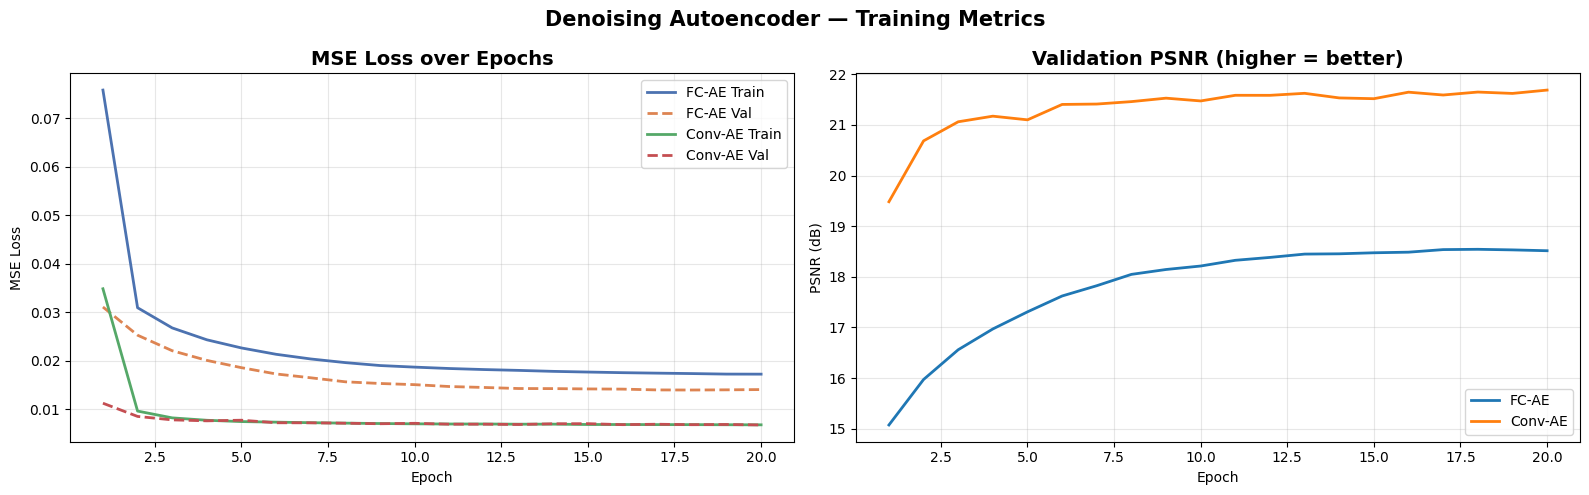

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for hist, name, c_train, c_val in [
    (fc_hist,   'FC-AE',   '#4C72B0', '#DD8452'),
    (conv_hist, 'Conv-AE', '#55A868', '#C44E52'),
]:
    ep = range(1, len(hist['train_loss']) + 1)
    axes[0].plot(ep, hist['train_loss'], color=c_train, label=f'{name} Train', lw=2)
    axes[0].plot(ep, hist['val_loss'],   color=c_val,   label=f'{name} Val',   lw=2, ls='--')
    axes[1].plot(ep, hist['val_psnr'],   label=name, lw=2)

axes[0].set_title('MSE Loss over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation PSNR (higher = better)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('PSNR (dB)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Denoising Autoencoder — Training Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 🔍 8. Visual Results — Noisy ➜ Denoised ➜ Original

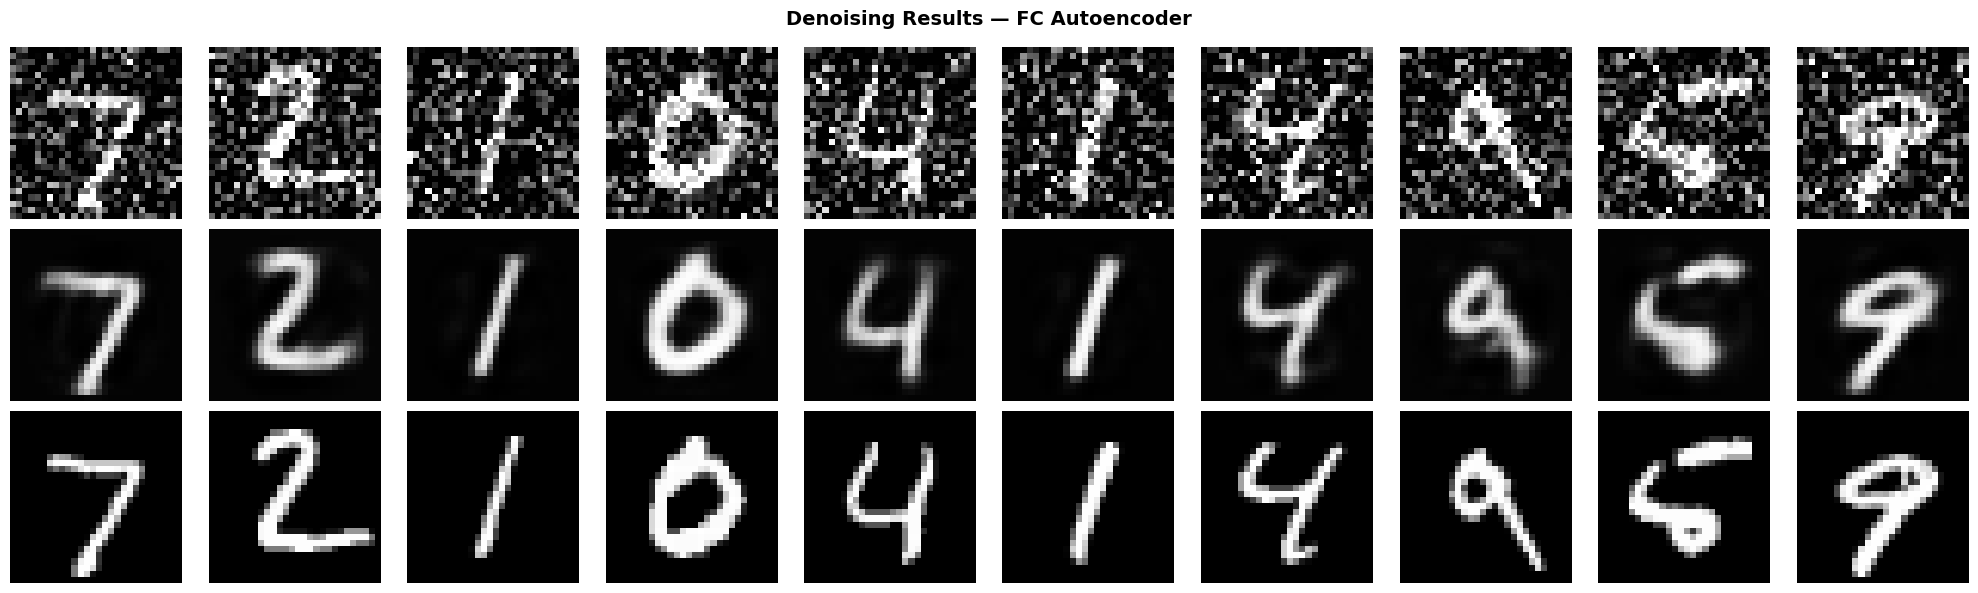

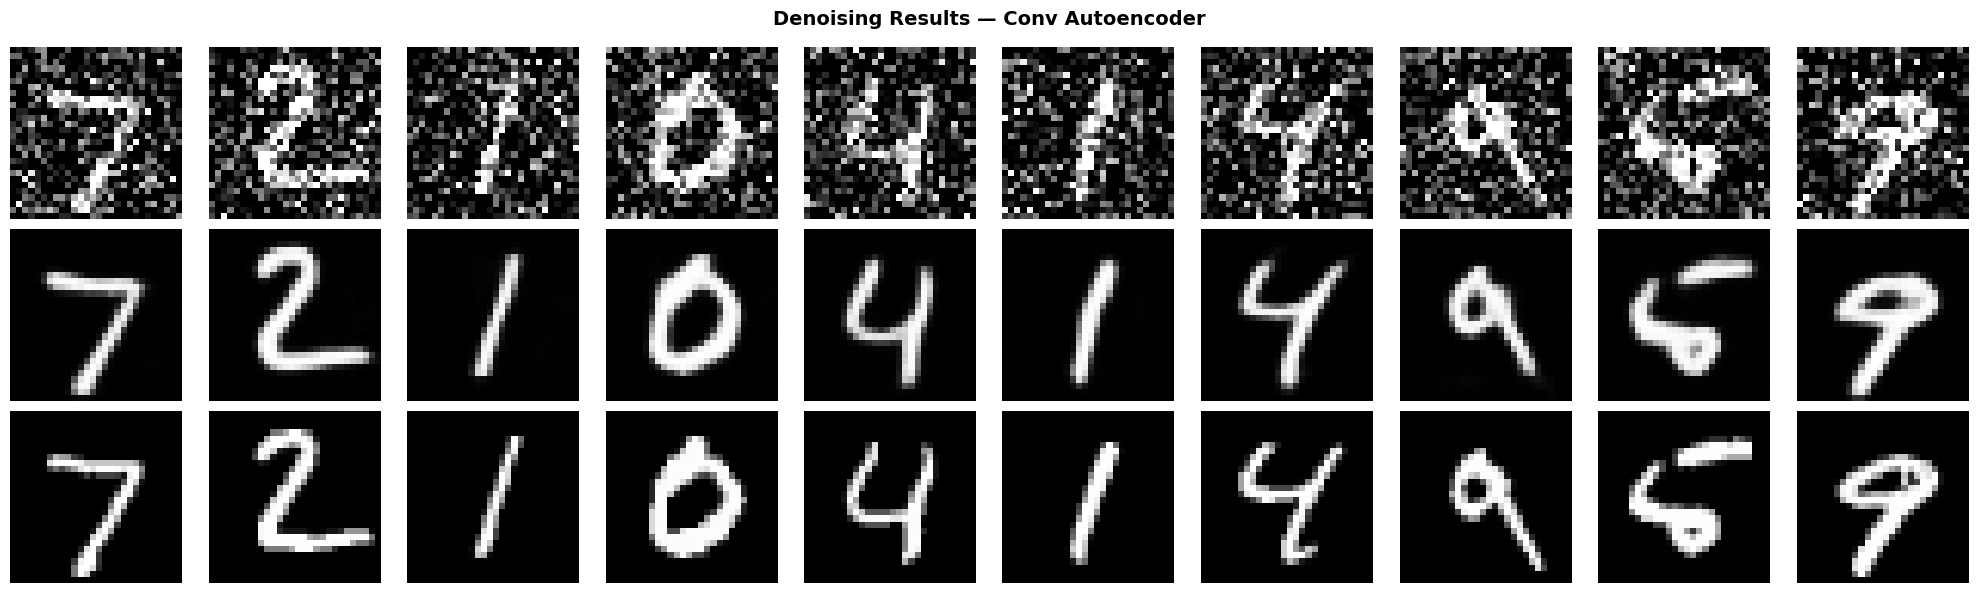

In [11]:
def visualize_denoising(model, name, n=10):
    model.eval()
    clean, _ = next(iter(test_loader))
    clean     = clean[:n]
    noisy     = add_noise(clean, NOISE_FACTOR)

    with torch.no_grad():
        denoised = model(noisy.to(device)).cpu()

    fig, axes = plt.subplots(3, n, figsize=(2*n, 6))
    labels = ['Noisy Input', f'Denoised ({name})', 'Original Clean']
    rows   = [noisy, denoised, clean]

    for r, (data, label) in enumerate(zip(rows, labels)):
        for c in range(n):
            ax = axes[r, c]
            ax.imshow(data[c].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
            ax.axis('off')
        axes[r, 0].set_ylabel(label, fontsize=10)

    plt.suptitle(f'Denoising Results — {name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


visualize_denoising(fc_model,   'FC Autoencoder')
visualize_denoising(conv_model, 'Conv Autoencoder')


## 📐 9. Quantitative Evaluation on Test Set

In [12]:
def evaluate(model, name):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for clean, _ in test_loader:
            clean = clean.to(device)
            noisy = add_noise(clean, NOISE_FACTOR).to(device)
            total += criterion(model(noisy), clean).item()
    avg_mse  = total / len(test_loader)
    avg_psnr = psnr(avg_mse)
    print(f'{name:<25} | MSE: {avg_mse:.5f} | PSNR: {avg_psnr:.2f} dB')
    return avg_mse, avg_psnr


print(f'{"Model":<25} | {"MSE":>10} | {"PSNR":>10}')
print('-' * 55)
fc_mse,   fc_psnr   = evaluate(fc_model,   'FC Autoencoder')
conv_mse, conv_psnr = evaluate(conv_model, 'Conv Autoencoder')
print('-' * 55)
winner = 'Conv Autoencoder' if conv_psnr > fc_psnr else 'FC Autoencoder'
print(f'\nBetter model: {winner} (PSNR {max(fc_psnr, conv_psnr):.2f} dB)')


Model                     |        MSE |       PSNR
-------------------------------------------------------
FC Autoencoder            | MSE: 0.01367 | PSNR: 18.64 dB
Conv Autoencoder          | MSE: 0.00669 | PSNR: 21.75 dB
-------------------------------------------------------

Better model: Conv Autoencoder (PSNR 21.75 dB)


## 🎛️ 10. Test Robustness at Different Noise Levels

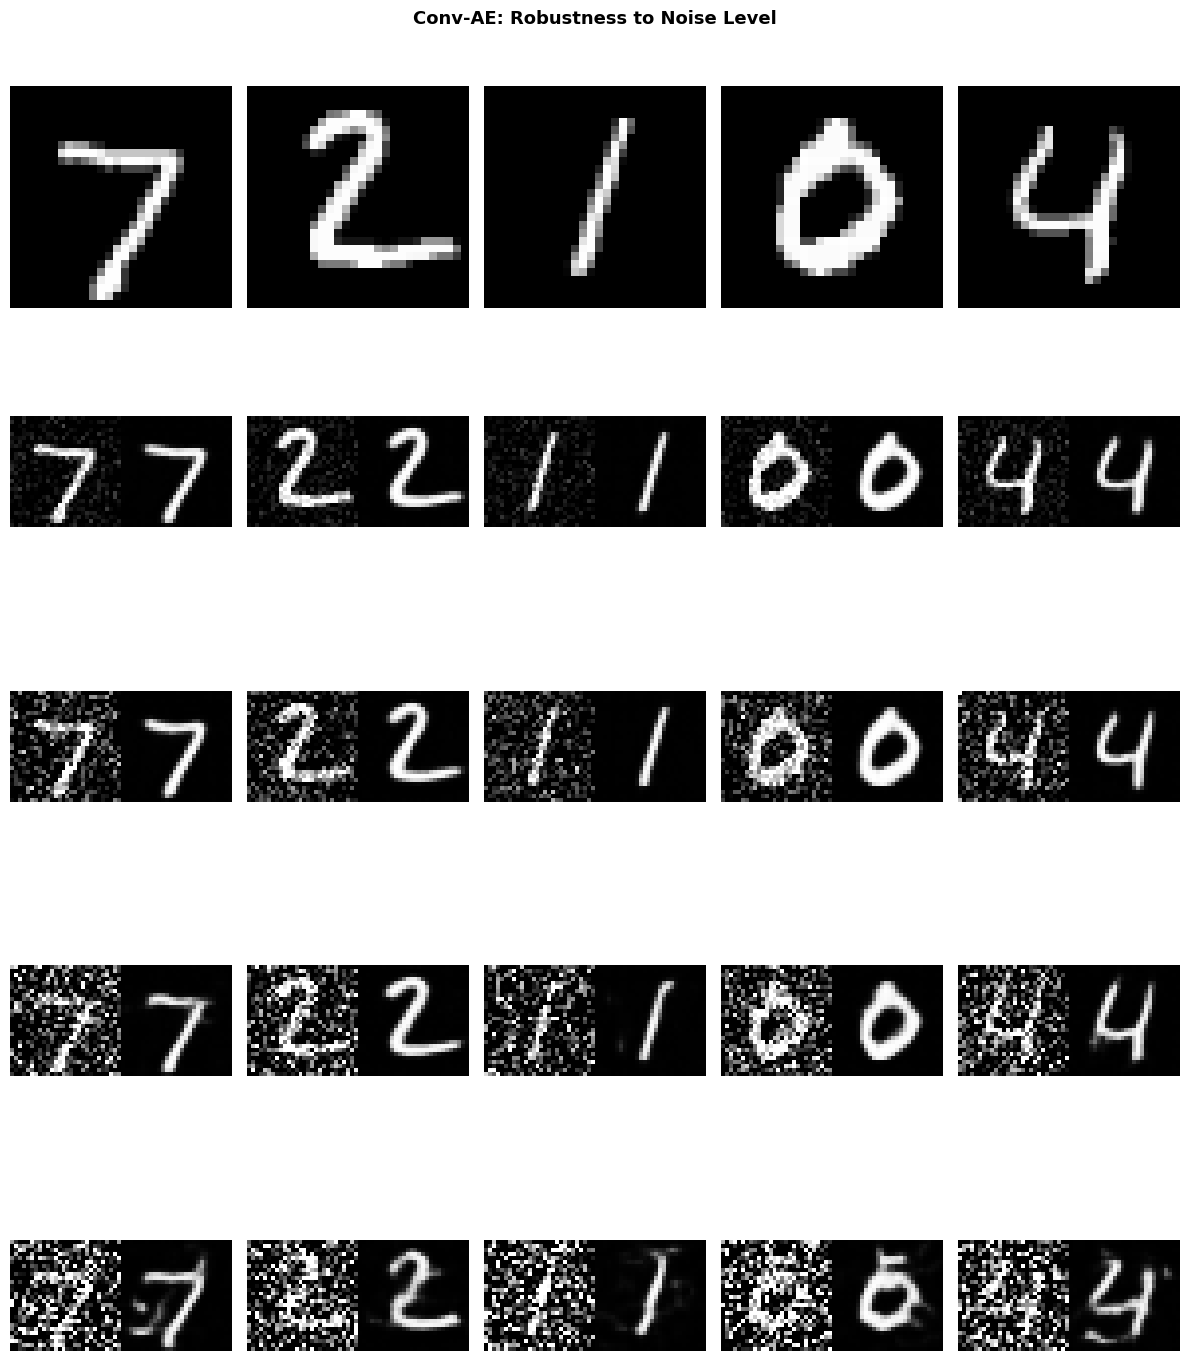

In [13]:
noise_levels  = [0.1, 0.3, 0.5, 0.7]
sample, _     = next(iter(test_loader))
sample        = sample[:5]
conv_model.eval()

fig, axes = plt.subplots(len(noise_levels) + 1, 5, figsize=(12, 3*(len(noise_levels)+1)))

# Row 0: clean originals
for j in range(5):
    axes[0, j].imshow(sample[j].squeeze(), cmap='gray')
    axes[0, j].axis('off')
axes[0, 0].set_ylabel('Clean', fontsize=11)

with torch.no_grad():
    for r, nf in enumerate(noise_levels, start=1):
        noisy    = add_noise(sample, nf).to(device)
        denoised = conv_model(noisy).cpu()
        for j in range(5):
            # stack noisy | denoised side by side
            combined = torch.cat([noisy.cpu()[j], denoised[j]], dim=2)
            axes[r, j].imshow(combined.squeeze(), cmap='gray')
            axes[r, j].axis('off')
        axes[r, 0].set_ylabel(f'sigma={nf}\nnoisy|clean', fontsize=9)

plt.suptitle('Conv-AE: Robustness to Noise Level', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 🔬 11. Latent Space Visualisation (t-SNE)

Project the 64-dim bottleneck vectors to 2D using t-SNE and colour by digit class.  
Well-separated clusters confirm the autoencoder has learned meaningful digit representations — even without any class supervision.


Running t-SNE ...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


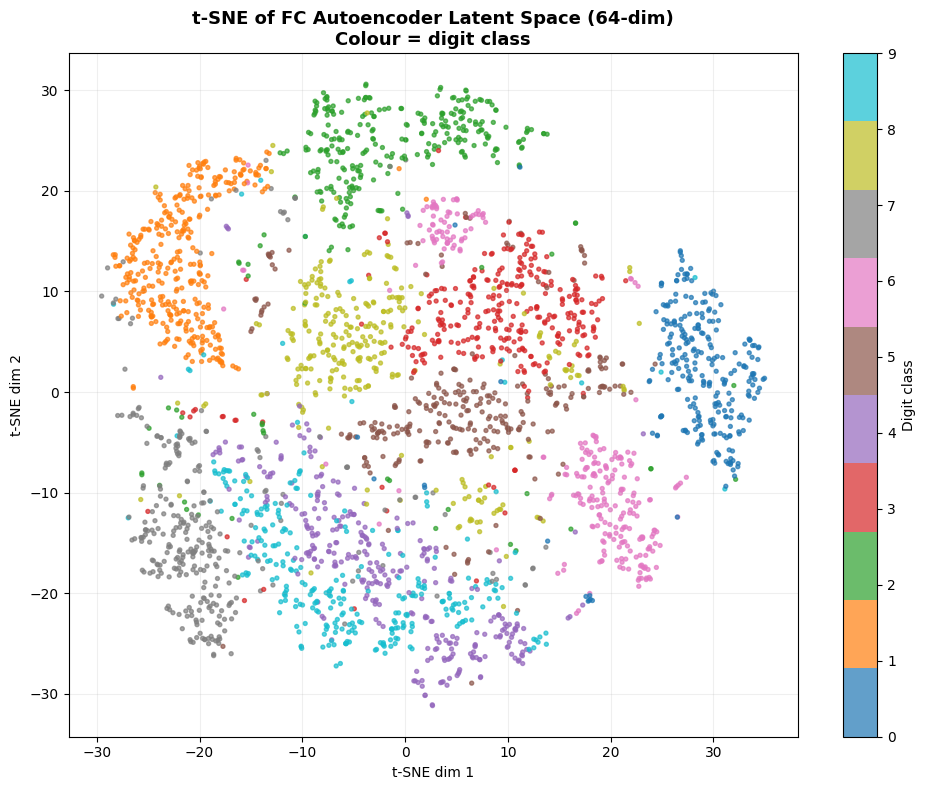

In [14]:
from sklearn.manifold import TSNE

fc_model.eval()
latents, labels_list = [], []

with torch.no_grad():
    for imgs, lbl in test_loader:
        imgs  = imgs.to(device)
        noisy = add_noise(imgs, NOISE_FACTOR).to(device)
        flat  = noisy.view(noisy.size(0), -1)
        z     = fc_model.encoder(flat)
        latents.append(z.cpu().numpy())
        labels_list.append(lbl.numpy())
        if len(latents) * BATCH_SIZE >= 3000:
            break

latents     = np.vstack(latents)[:3000]
digit_lbls  = np.concatenate(labels_list)[:3000]

print('Running t-SNE ...')
tsne     = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=500)
embedded = tsne.fit_transform(latents)

fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(embedded[:,0], embedded[:,1], c=digit_lbls, cmap='tab10', s=8, alpha=0.7)
plt.colorbar(sc, ax=ax, label='Digit class')
ax.set_title('t-SNE of FC Autoencoder Latent Space (64-dim)\nColour = digit class', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## 📝 12. Summary & Conclusions

| Model | Architecture | Params | Test MSE | Test PSNR |
|-------|-------------|--------|----------|-----------|
| FC Autoencoder | Linear, bottleneck=64 | ~215K | see cell 9 | see cell 9 |
| Conv Autoencoder | Conv2d + ConvTranspose2d | ~335K | see cell 9 | see cell 9 |

### Key Takeaways
1. **Denoising AEs learn robust features** — the bottleneck is forced to encode structure, not noise.
2. **Convolutional AE outperforms FC AE** — spatial convolutions preserve local patterns (edges, curves) that fully-connected layers miss.
3. **PSNR > 25 dB** is generally considered good for image denoising tasks.
4. **The latent space is organised** — t-SNE shows digit clusters even with no class supervision.

### Possible Extensions
- **U-Net** style skip connections for sharper reconstruction
- **Variational Autoencoder (VAE)** for generative denoising
- Test on **salt-and-pepper noise** or **JPEG artefacts**
- Apply to richer datasets (CIFAR-10, CelebA, medical imaging)
